In [31]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import time

from numba import cuda

def load_and_display_image(file_path):
        img = mpimg.imread(file_path)

        print(f"Image shape: {img.shape}")

        # plt.imshow(img)
        # plt.axis('off')
        # plt.show()

        return img

image_path = "image.jpg"
img = load_and_display_image(image_path)

h = img.shape[0]
w = img.shape[1]

pixelCount = h*w
blockSize = 64
gridSize = int(pixelCount/blockSize)



Image shape: (6000, 3375, 3)


GPU time: 0.0002353191375732422 seconds


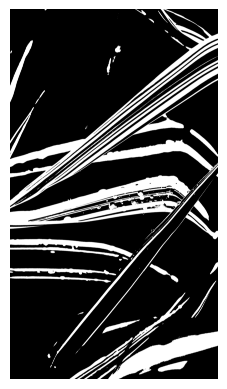

In [3]:
import math
blockSize = (8, 8)

gridSize = (
    math.ceil(w / blockSize[0]),
    math.ceil(h / blockSize[1])
)

@cuda.jit
def grayscale_bi(src, dst):
    x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

    if x < src.shape[1] and y < src.shape[0]:
        g = np.uint8(
            (int(src[y, x, 0]) +
             int(src[y, x, 1]) +
             int(src[y, x, 2])) / 3
        )

        if(g > 128):
          dst[y, x, 0] = 255
          dst[y, x, 1] = 255
          dst[y, x, 2] = 255
        else:
          dst[y, x, 0] = 0
          dst[y, x, 1] = 0
          dst[y, x, 2] = 0


devSrc = cuda.to_device(img)
devDst = cuda.device_array((h, w, 3), np.uint8)

grayscale_bi[gridSize, blockSize](devSrc, devDst)

hostDst = devDst.copy_to_host()

start_gpu = time.time()

grayscale_bi[gridSize, blockSize](devSrc, devDst)

end_gpu = time.time()

gpu_time = end_gpu - start_gpu

hostDst = devDst.copy_to_host()

print("GPU time:", gpu_time, "seconds")

plt.imshow(hostDst)
plt.axis('off')
plt.show()


In [4]:
block_sizes = [
    (8,8),
    (16,16),
    (32,16),
    (16,32),
    (32,32)
]
gpu_times = []

for blockSize in block_sizes:

    gridSize = (
        math.ceil(w / blockSize[0]),
        math.ceil(h / blockSize[1])
    )

    devSrc = cuda.to_device(img)
    devDst = cuda.device_array((h, w, 3), np.uint8)

    grayscale_bi[gridSize, blockSize](devSrc, devDst)
    hostDst = devDst.copy_to_host()

    times = []

    for i in range(5):

        start = time.time()

        grayscale_bi[gridSize, blockSize](devSrc, devDst)

        end = time.time()

        times.append(end - start)
        hostDst = devDst.copy_to_host()

    average_time = sum(times) / 5

    gpu_times.append(average_time)
    # plt.imshow(hostDst)
    # plt.axis('off')
    # plt.show()

    print("Block size:", blockSize)
    print("Times:", times)
    print("Average:", average_time)

Block size: (8, 8)
Times: [0.0001735687255859375, 0.0001652240753173828, 0.00016236305236816406, 0.0001506805419921875, 0.0001499652862548828]
Average: 0.00016036033630371094
Block size: (16, 16)
Times: [0.00016355514526367188, 0.0001475811004638672, 0.00013446807861328125, 0.0001385211944580078, 0.00014066696166992188]
Average: 0.00014495849609375
Block size: (32, 16)
Times: [0.00014495849609375, 0.0010271072387695312, 0.0001819133758544922, 0.00020432472229003906, 0.0001575946807861328]
Average: 0.0003431797027587891
Block size: (16, 32)
Times: [0.0002346038818359375, 0.00017452239990234375, 0.0001552104949951172, 0.00014448165893554688, 0.00014090538024902344]
Average: 0.00016994476318359374
Block size: (32, 32)
Times: [0.00015020370483398438, 0.0001437664031982422, 0.0001068115234375, 0.0001552104949951172, 0.00011229515075683594]
Average: 0.00013365745544433594


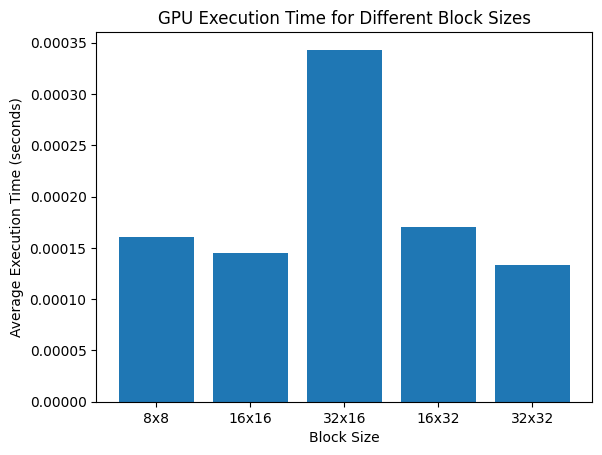

In [6]:
labels = [f"{x}x{y}" for x, y in block_sizes]

plt.bar(labels, gpu_times)

plt.xlabel("Block Size")
plt.ylabel("Average Execution Time (seconds)")
plt.title("GPU Execution Time for Different Block Sizes")

plt.show()

GPU time: 0.0022950172424316406 seconds


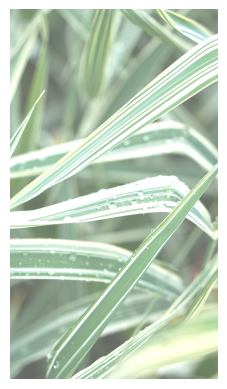

In [16]:
blockSize = (8, 8)

gridSize = (
    math.ceil(w / blockSize[0]),
    math.ceil(h / blockSize[1])
)

b = 100

@cuda.jit
def img_bri(src, dst, b):
    x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

    if x < src.shape[1] and y < src.shape[0]:

        dst[y, x, 0] = min(src[y, x, 0] + b, 255)
        dst[y, x, 1] = min(src[y, x, 1] + b, 255)
        dst[y, x, 2] = min(src[y, x, 2] + b, 255)


devSrc = cuda.to_device(img)
devDst = cuda.device_array((h, w, 3), np.uint8)

# warm-up
img_bri[gridSize, blockSize](devSrc, devDst, b)
cuda.synchronize()

start_gpu = time.time()

img_bri[gridSize, blockSize](devSrc, devDst, b)
cuda.synchronize()

end_gpu = time.time()

gpu_time = end_gpu - start_gpu

hostDst = devDst.copy_to_host()

print("GPU time:", gpu_time, "seconds")

plt.imshow(hostDst)
plt.axis('off')
plt.show()

Block size: (8, 8)
Times: [0.0001571178436279297, 0.0001823902130126953, 0.00013685226440429688, 0.00012159347534179688, 0.0001404285430908203]
Average: 0.0001476764678955078
Block size: (16, 16)
Times: [0.0001480579376220703, 0.0001914501190185547, 0.00014472007751464844, 0.00020551681518554688, 0.00014495849609375]
Average: 0.00016694068908691407
Block size: (32, 16)
Times: [0.0001728534698486328, 0.00017833709716796875, 0.00012874603271484375, 0.00012063980102539062, 0.0001633167266845703]
Average: 0.00015277862548828124
Block size: (16, 32)
Times: [0.00013208389282226562, 0.0001773834228515625, 0.00014638900756835938, 0.00012087821960449219, 0.0001227855682373047]
Average: 0.00013990402221679686
Block size: (32, 32)
Times: [0.00012493133544921875, 0.000133514404296875, 0.00012755393981933594, 0.00013184547424316406, 0.00013208389282226562]
Average: 0.00012998580932617189


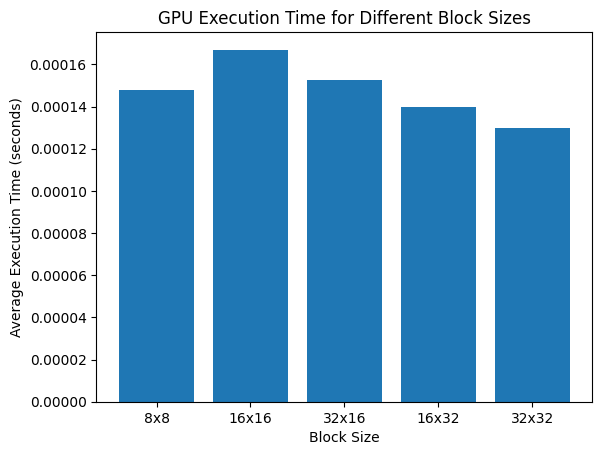

In [18]:
block_sizes = [
    (8,8),
    (16,16),
    (32,16),
    (16,32),
    (32,32)
]
gpu_times = []

b = 50

for blockSize in block_sizes:

    gridSize = (
        math.ceil(w / blockSize[0]),
        math.ceil(h / blockSize[1])
    )

    devSrc = cuda.to_device(img)
    devDst = cuda.device_array((h, w, 3), np.uint8)

    img_bri[gridSize, blockSize](devSrc, devDst, b)
    hostDst = devDst.copy_to_host()

    times = []

    for i in range(5):

        start = time.time()

        img_bri[gridSize, blockSize](devSrc, devDst, b)

        end = time.time()

        times.append(end - start)
        hostDst = devDst.copy_to_host()

    average_time = sum(times) / 5

    gpu_times.append(average_time)
    # plt.imshow(hostDst)
    # plt.axis('off')
    # plt.show()

    print("Block size:", blockSize)
    print("Times:", times)
    print("Average:", average_time)

    labels = [f"{x}x{y}" for x, y in block_sizes]

plt.bar(labels, gpu_times)

plt.xlabel("Block Size")
plt.ylabel("Average Execution Time (seconds)")
plt.title("GPU Execution Time for Different Block Sizes")

plt.show()

Image shape: (6000, 4000, 3)
(6000, 3375, 3)


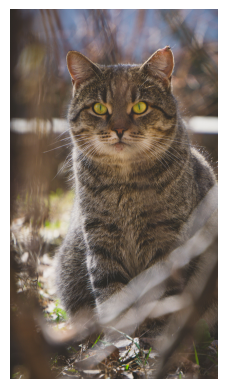

In [28]:
image_path = "image2.jpg"
img2 = load_and_display_image(image_path)
img2 = np.ascontiguousarray(img2[:, :3375, :])
print(img2.shape)


plt.imshow(img2)
plt.axis('off')
plt.show()

GPU time: 0.008265018463134766 seconds


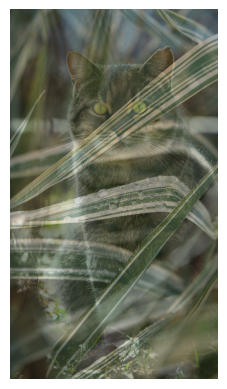

In [32]:
blockSize = (8, 8)

gridSize = (
    math.ceil(w / blockSize[0]),
    math.ceil(h / blockSize[1])
)

@cuda.jit
def blend_im(src1, src2, dst, w):
    x = cuda.threadIdx.x + cuda.blockIdx.x * cuda.blockDim.x
    y = cuda.threadIdx.y + cuda.blockIdx.y * cuda.blockDim.y

    if (x < src1.shape[1] and y < src1.shape[0] and
        x < src2.shape[1] and y < src2.shape[0]):

        dst[y, x, 0] = w*src1[y, x, 0] + (1-w)*src2[y, x, 0]
        dst[y, x, 1] = w*src1[y, x, 1] + (1-w)*src2[y, x, 1]
        dst[y, x, 2] = w*src1[y, x, 2] + (1-w)*src2[y, x, 2]


devSrc1 = cuda.to_device(img)
devSrc2 = cuda.to_device(img2)
devDst = cuda.device_array((h, w, 3), np.uint8)
w0 = 0.5

# warm-up
blend_im[gridSize, blockSize](devSrc1, devSrc2, devDst,w0)
cuda.synchronize()

start_gpu = time.time()

blend_im[gridSize, blockSize](devSrc1, devSrc2, devDst,w0)
cuda.synchronize()

end_gpu = time.time()

gpu_time = end_gpu - start_gpu

hostDst = devDst.copy_to_host()

print("GPU time:", gpu_time, "seconds")

plt.imshow(hostDst)
plt.axis('off')
plt.show()

Block size: (8, 8)
Times: [0.00023674964904785156, 0.00020170211791992188, 0.0002574920654296875, 0.00024390220642089844, 0.00017213821411132812]
Average: 0.0002223968505859375
Block size: (16, 16)
Times: [0.00015926361083984375, 0.000232696533203125, 0.00024819374084472656, 0.0002009868621826172, 0.0002512931823730469]
Average: 0.00021848678588867187
Block size: (32, 16)
Times: [0.0001647472381591797, 0.00016307830810546875, 0.00017261505126953125, 0.0002448558807373047, 0.000209808349609375]
Average: 0.00019102096557617189
Block size: (16, 32)
Times: [0.00022125244140625, 0.00015735626220703125, 0.0001652240753173828, 0.0002079010009765625, 0.00021958351135253906]
Average: 0.00019426345825195311
Block size: (32, 32)
Times: [0.00017452239990234375, 0.0001506805419921875, 0.00020599365234375, 0.00017261505126953125, 0.00021266937255859375]
Average: 0.00018329620361328124


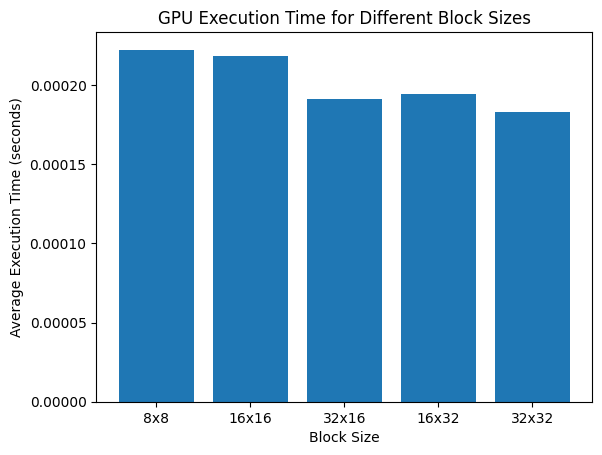

In [33]:
block_sizes = [
    (8,8),
    (16,16),
    (32,16),
    (16,32),
    (32,32)
]
gpu_times = []

b = 50

for blockSize in block_sizes:

    gridSize = (
        math.ceil(w / blockSize[0]),
        math.ceil(h / blockSize[1])
    )

    devSrc = cuda.to_device(img)
    devDst = cuda.device_array((h, w, 3), np.uint8)

    blend_im[gridSize, blockSize](devSrc1, devSrc2, devDst,w0)
    hostDst = devDst.copy_to_host()

    times = []

    for i in range(5):

        start = time.time()

        blend_im[gridSize, blockSize](devSrc1, devSrc2, devDst,w0)

        end = time.time()

        times.append(end - start)
        hostDst = devDst.copy_to_host()

    average_time = sum(times) / 5

    gpu_times.append(average_time)
    # plt.imshow(hostDst)
    # plt.axis('off')
    # plt.show()

    print("Block size:", blockSize)
    print("Times:", times)
    print("Average:", average_time)

    labels = [f"{x}x{y}" for x, y in block_sizes]

plt.bar(labels, gpu_times)

plt.xlabel("Block Size")
plt.ylabel("Average Execution Time (seconds)")
plt.title("GPU Execution Time for Different Block Sizes")

plt.show()